In [11]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, style_ax, legend

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import-afhængighed: fossile brændsler vs. elektricitet

Replikation af Ember-figuren: sammenligning af EU-27 og Danmark.

**Venstre panel** — Fossil forsyning fra indenlandske kilder (%):
$$\text{Indenlandsk andel} = \frac{\text{PPRD}}{\text{PPRD} + \text{IMP} - \text{EXP}}$$
Fossil defineret som: fast fossil brændsel (`H8000`), naturgas (`G3000`), olie og olieprodukter (`O4000XBIO`).

**Højre panel** — Elproduktion fra indenlandske kilder (%):
$$\text{Ekskl. kernekraft} = \frac{\text{GEP}_{\text{VE}}}{\text{GEP}_{\text{total}}} \qquad \text{Inkl. kernekraft} = \frac{\text{GEP}_{\text{VE}} + \text{GEP}_{\text{kern.}}}{\text{GEP}_{\text{total}}}$$
VE (`RA000`), kernekraft (`N900H`). Kilde: Eurostat `nrg_bal_c`.

In [12]:
import xml.etree.ElementTree as ET

_G    = 'http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic'
_BASE = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/nrg_bal_c'

def _parse(r):
    r.raise_for_status()
    root = ET.fromstring(r.text)
    rows = []
    for series in root.iter(f'{{{_G}}}Series'):
        sk   = series.find(f'{{{_G}}}SeriesKey')
        dims = {v.get('id'): v.get('value') for v in sk.findall(f'{{{_G}}}Value')}
        for obs in series.iter(f'{{{_G}}}Obs'):
            year   = obs.find(f'{{{_G}}}ObsDimension').get('value')
            val_el = obs.find(f'{{{_G}}}ObsValue')
            val    = float(val_el.get('value')) if val_el is not None else None
            rows.append({**dims, 'year': int(year), 'value': val})
    return pd.DataFrame(rows)

COUNTRIES = ['EU27_2020']
geo_key   = '+'.join(COUNTRIES)

# Fossil SIECs: solid fossil fuels + natural gas + oil&petroleum products (excl. biofuels)
FOSSIL_SIECS = ['H8000', 'G3000', 'O4000XBIO']
fos_key      = '+'.join(FOSSIL_SIECS)

In [13]:
# Primary production, imports, exports — all fossil SIECs, both countries
df_fos = _parse(requests.get(
    f'{_BASE}/A.PPRD+IMP+EXP.{fos_key}.TJ.{geo_key}?startPeriod=1995'
))

print('nrg_bal:', df_fos.nrg_bal.unique())
print('siec:   ', df_fos.siec.unique())
print('shape:  ', df_fos.shape)
df_fos.head()

nrg_bal: ['EXP' 'IMP' 'PPRD']
siec:    ['G3000' 'H8000' 'O4000XBIO']
shape:   (270, 7)


,geo,siec,unit,freq,nrg_bal,year,value
0,EU27_2020,G3000,TJ,A,EXP,1995,1412492.764
1,EU27_2020,G3000,TJ,A,EXP,1996,1684481.341
2,EU27_2020,G3000,TJ,A,EXP,1997,1567443.622
3,EU27_2020,G3000,TJ,A,EXP,1998,1442465.633
4,EU27_2020,G3000,TJ,A,EXP,1999,1460466.542


In [14]:
# Gross electricity production: total, renewables (RA000), nuclear (N900H)
df_elec = _parse(requests.get(
    f'{_BASE}/A.GEP.TOTAL+RA000+N900H.TJ.{geo_key}?startPeriod=1995'
))

print('nrg_bal:', df_elec.nrg_bal.unique())
print('siec:   ', df_elec.siec.unique())
print('shape:  ', df_elec.shape)
df_elec.head()

nrg_bal: ['GEP']
siec:    ['N900H' 'RA000' 'TOTAL']
shape:   (90, 7)


,geo,siec,unit,freq,nrg_bal,year,value
0,EU27_2020,N900H,TJ,A,GEP,1995,2850685.2
1,EU27_2020,N900H,TJ,A,GEP,1996,2992564.8
2,EU27_2020,N900H,TJ,A,GEP,1997,3022113.6
3,EU27_2020,N900H,TJ,A,GEP,1998,3000114.0
4,EU27_2020,N900H,TJ,A,GEP,1999,3053703.6


In [15]:
# Sum across fossil types, then compute domestic share per country-year
fos_agg = (
    df_fos.dropna(subset=['value'])
    .groupby(['geo', 'year', 'nrg_bal'])['value']
    .sum()
    .unstack('nrg_bal')
    .fillna(0)
    .reset_index()
)

fos_agg['domestic_pct'] = (
    fos_agg['PPRD'] / (fos_agg['PPRD'] + fos_agg['IMP'] - fos_agg['EXP']) * 100
)

# Sanity: EU27 domestic share should be low (~20-30%) and declining
fos_agg[fos_agg.geo == 'EU27_2020'][['year', 'PPRD', 'IMP', 'EXP', 'domestic_pct']].tail(10)

nrg_bal,year,PPRD,IMP,EXP,domestic_pct
20,2015,4254116.690,4.830395e+07,1.756858e+07,12.158270
21,2016,4092072.487,4.888753e+07,1.762852e+07,11.575523
22,2017,3884758.308,5.009926e+07,1.730736e+07,10.591908
23,2018,3555975.331,4.863284e+07,1.564198e+07,9.729914
24,2019,3179419.325,4.974642e+07,1.508619e+07,8.402349
25,2020,2665287.775,4.413789e+07,1.341448e+07,7.982606
26,2021,2468194.176,4.568991e+07,1.459242e+07,7.353325
27,2022,2274518.696,4.834245e+07,1.526714e+07,6.434312
28,2023,2040427.797,4.582430e+07,1.552782e+07,6.309905
29,2024,1956739.181,4.519461e+07,1.503910e+07,6.093436


In [16]:
# Pivot electricity by SIEC, then compute domestic shares
elec_piv = (
    df_elec.dropna(subset=['value'])
    .pivot_table(index=['geo', 'year'], columns='siec', values='value')
    .reset_index()
)

elec_piv['dom_excl_nuc'] = elec_piv['RA000'] / elec_piv['TOTAL'] * 100
elec_piv['dom_incl_nuc'] = (elec_piv['RA000'] + elec_piv['N900H']) / elec_piv['TOTAL'] * 100

# Sanity: EU27 renewable share of electricity should be ~40-50% recently
elec_piv[elec_piv.geo == 'EU27_2020'][['year', 'RA000', 'N900H', 'TOTAL', 'dom_excl_nuc', 'dom_incl_nuc']].tail(10)

siec,year,RA000,N900H,TOTAL,dom_excl_nuc,dom_incl_nuc
20,2015,3085442.026,2832033.057,1.046567e+07,29.481552,56.541768
21,2016,3140388.611,2764651.536,1.054333e+07,29.785541,56.007341
22,2017,3151340.723,2733777.514,1.065894e+07,29.565241,55.212988
23,2018,3388050.343,2742994.973,1.059863e+07,31.966868,57.847523
24,2019,3523502.236,2755216.281,1.046801e+07,33.659705,59.980042
25,2020,3817787.577,2460643.722,1.004470e+07,38.007969,62.504898
26,2021,3882848.483,2634122.855,1.049911e+07,36.982630,62.071631
27,2022,3893298.721,2193319.786,1.016473e+07,38.302055,59.879813
28,2023,4426166.716,2230564.720,9.939401e+06,44.531522,66.973162
29,2024,4797044.017,2338365.033,1.018344e+07,47.106304,70.068723


## Figur: Indenlandsk vs. importeret energi

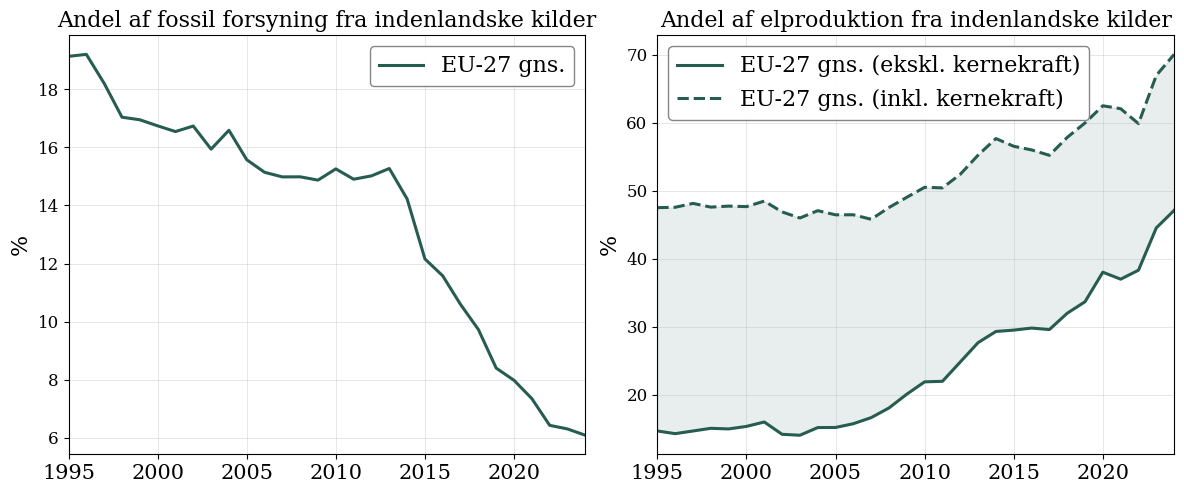

In [18]:
years_fos  = np.sort(fos_agg.year.unique())
years_elec = np.sort(elec_piv.year.unique())

fig, (ax_fos, ax_elec) = plt.subplots(1, 2, figsize=(12, 5))

for geo in COUNTRIES:
    c     = PALETTE[geo]
    lw    = LW[geo]
    name  = var_groups.country_names[geo]

    # Left panel — fossil domestic share
    sf = fos_agg[fos_agg.geo == geo].sort_values('year')
    ax_fos.plot(sf.year, sf.domestic_pct, color=c, lw=lw, label=name)

    # Right panel — electricity domestic share, excl / incl nuclear
    se = elec_piv[elec_piv.geo == geo].sort_values('year')
    ax_elec.plot(se.year, se.dom_excl_nuc, color=c, lw=lw, ls='-',
                 label=f'{name} (ekskl. kernekraft)')
    ax_elec.plot(se.year, se.dom_incl_nuc, color=c, lw=lw, ls='--',
                 label=f'{name} (inkl. kernekraft)')
    ax_elec.fill_between(se.year, se.dom_excl_nuc, se.dom_incl_nuc,
                         color=c, alpha=0.10)

# Formatting
ax_fos.set_ylabel('%')
ax_fos.set_title('Andel af fossil forsyning fra indenlandske kilder')
style_ax(ax_fos, years_fos, step=5)
legend(ax_fos, loc='upper right')

ax_elec.set_ylabel('%')
ax_elec.set_title('Andel af elproduktion fra indenlandske kilder')
style_ax(ax_elec, years_elec, step=5)
legend(ax_elec, ncol=1, loc='upper left')

plt.tight_layout()
plt.savefig('0_intermediate/fig_import_dependency.pdf')
plt.show()